# 01_EDA — LinkedIn Company Dataset
**Role:** TM2 · Data Science Lead  
**Dataset:** HarvestAPI LinkedIn Company Search (500 records)  
**Deliverables:** Correlation matrix · Feature importance validation · Sensitivity analysis  
**Output:** `feature_importance_validation.md`

## 1. Setup & Imports

In [2]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [4]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

print('Libraries loaded.')

Libraries loaded.


## 2. Load & Parse Raw JSON

In [7]:
with open(r'C:\Users\tarms\Downloads\dataset_linkedin-company-search_2026-06-17_10-26-36-514.json', encoding='utf-8', errors='replace') as f:
    raw = json.load(f)

print(f'Raw records loaded: {len(raw)}')
print(f'Available fields: {list(raw[0].keys())}')

Raw records loaded: 500
Available fields: ['id', 'universalName', 'linkedinUrl', 'name', 'tagline', 'website', 'phone', 'logo', 'foundedOn', 'employeeCount', 'employeeCountRange', 'followerCount', 'description', 'companyType', 'locations', 'specialities', 'industries', 'logos', 'backgroundCover', 'backgroundCovers', 'active', 'jobSearchUrl', 'pageVerified', 'pageType', 'autoGenerated', 'callToActionUrl', 'similarOrganizations', 'peopleStats', '_meta']


## 3. Flatten Nested Fields & Build Clean DataFrame

In [8]:
def parse_company(c):
    # Extract HQ location (first location marked as headquarter)
    locs = c.get('locations', [])
    hq = next((l for l in locs if l.get('headquarter')), locs[0] if locs else {})
    parsed = hq.get('parsed', {})

    # Extract industry
    industries = c.get('industries', [])
    industry_name = industries[0]['name'] if industries else None
    industry_hierarchy = industries[0].get('hierarchy', None) if industries else None

    # Extract founded year
    founded = c.get('foundedOn') or {}
    founded_year = founded.get('year') if isinstance(founded, dict) else None

    # Extract employee range
    emp_range = c.get('employeeCountRange') or {}
    emp_start = emp_range.get('start') if isinstance(emp_range, dict) else None
    emp_end = emp_range.get('end') if isinstance(emp_range, dict) else None

    # Specialties as pipe-separated string
    specialities = c.get('specialities', []) or []
    specialities_str = ' | '.join(specialities) if specialities else None
    speciality_count = len(specialities)

    return {
        'id': c.get('id'),
        'name': c.get('name'),
        'universal_name': c.get('universalName'),
        'linkedin_url': c.get('linkedinUrl'),
        'website': c.get('website'),
        'tagline': c.get('tagline'),
        'description': c.get('description'),
        'company_type': c.get('companyType'),
        'industry': industry_name,
        'industry_hierarchy': industry_hierarchy,
        'employee_count': c.get('employeeCount'),
        'employee_range_start': emp_start,
        'employee_range_end': emp_end,
        'follower_count': c.get('followerCount'),
        'founded_year': founded_year,
        'country': hq.get('country'),
        'city': parsed.get('city') or hq.get('city'),
        'country_full': parsed.get('countryFull'),
        'specialities': specialities_str,
        'speciality_count': speciality_count,
        'active': c.get('active'),
        'page_verified': c.get('pageVerified'),
    }

df_raw = pd.DataFrame([parse_company(c) for c in raw])
print(f'Parsed shape: {df_raw.shape}')
df_raw.head(3)

Parsed shape: (500, 22)


,id,name,universal_name,linkedin_url,website,tagline,description,company_type,industry,industry_hierarchy,...,employee_range_end,follower_count,founded_year,country,city,country_full,specialities,speciality_count,active,page_verified
0,82138326,Example B2B SaaS Marketing Recruitment | Speci...,example-digital,https://www.linkedin.com/company/example-digital/,https://theexample.co.uk,Specialists in B2B SaaS Marketing Recruitment,"We help B2B, SaaS & Tech brands drive growth b...",Privately Held,Staffing and Recruiting,Administrative and Support Services > Staffing...,...,10,1154,2022.0,GB,London,United Kingdom,recruitment | digital strategy | talent acquis...,5,True,False
1,10812751,B2B Rocks 🎸,b2b-rocks,https://www.linkedin.com/company/b2b-rocks/,https://www.b2brocks.co/,People and Content focused on Unlocking Intern...,B2B Rocks provides SaaS leaders with direct ac...,Privately Held,Events Services,Administrative and Support Services > Events S...,...,10,5285,2013.0,FR,Paris,France,B2B Startups Event | SaaS Startups Event | B2B...,24,None,False
2,98684827,GrowUp | B2B SaaS SEO Agency,b2b-saas-seo-agency,https://www.linkedin.com/company/b2b-saas-seo-...,https://www.seo-growup.com?utm_source=linkedin...,Integrate search into your GTM motion as a mea...,Search lives adjacent to go-to-market in most ...,Privately Held,Advertising Services,Professional Services > Advertising Services,...,1,130,2024.0,GB,London,United Kingdom,B2B SaaS SEO Consulting | B2B SaaS Content Mar...,3,None,False


## 4. Deduplication

In [10]:
before = len(df_raw)
df_raw = df_raw.drop_duplicates(subset=['id'])
df_raw = df_raw.drop_duplicates(subset=['linkedin_url'])
after = len(df_raw)

print(f'Before dedup: {before} | After dedup: {after} | Removed: {before - after}')

Before dedup: 500 | After dedup: 500 | Removed: 0


## 5. Filter: Small Companies Only (≤ 20 Employees)

In [11]:
df = df_raw[df_raw['employee_count'].notna()].copy()
df = df[df['employee_count'] <= 20].copy()
df = df[df['active'] == True].copy()

print(f'Companies with ≤20 employees (active): {len(df)}')
print(f'\nCountry distribution:')
print(df['country'].value_counts().head(10))

Companies with ≤20 employees (active): 195

Country distribution:
country
US    162
GB     25
DE      2
IN      2
FR      1
IE      1
SG      1
us      1
Name: count, dtype: int64


## 6. Data Availability Assessment

In [13]:
print('=== DATA AVAILABILITY ASSESSMENT ===')
print(f'Total raw records:         {len(raw)}')
print(f'After deduplication:       {len(df_raw)}')
print(f'After size filter (≤20):   {len(df)}')
print()
print('--- Missing values per field ---')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
availability = pd.DataFrame({'missing': missing, 'missing_%': missing_pct})
print(availability[availability['missing'] > 0].sort_values('missing_%', ascending=False))
print()
print('--- Key fields completeness ---')
key_fields = ['employee_count', 'founded_year', 'industry', 'country', 'follower_count', 'specialities', 'description']
for f in key_fields:
    pct = (df[f].notna().sum() / len(df) * 100)
    print(f'  {f:<20} {pct:.0f}% complete')

=== DATA AVAILABILITY ASSESSMENT ===
Total raw records:         500
After deduplication:       500
After size filter (≤20):   195

--- Missing values per field ---
                    missing  missing_%
founded_year             25       12.8
specialities             24       12.3
tagline                   5        2.6
website                   1        0.5
industry_hierarchy        1        0.5
city                      1        0.5

--- Key fields completeness ---
  employee_count       100% complete
  founded_year         87% complete
  industry             100% complete
  country              100% complete
  follower_count       100% complete
  specialities         88% complete
  description          100% complete


## 7. Feature Engineering

In [14]:
current_year = 2026

# Company age
df['company_age'] = current_year - df['founded_year']
df['company_age'] = df['company_age'].clip(0, 50)  # remove outliers

# Followers per employee (marketing maturity proxy)
df['followers_per_employee'] = (df['follower_count'] / df['employee_count']).round(1)

# Has website
df['has_website'] = df['website'].notna().astype(int)

# Has tagline
df['has_tagline'] = df['tagline'].notna().astype(int)

# Description length (content maturity signal)
df['description_length'] = df['description'].fillna('').apply(len)

# Verified page
df['is_verified'] = df['page_verified'].fillna(False).astype(int)

print('Engineered features added:')
print('  company_age, followers_per_employee, has_website, has_tagline, description_length, is_verified')
df[['name', 'employee_count', 'company_age', 'followers_per_employee', 'speciality_count']].head(5)

Engineered features added:
  company_age, followers_per_employee, has_website, has_tagline, description_length, is_verified


,name,employee_count,company_age,followers_per_employee,speciality_count
0,Example B2B SaaS Marketing Recruitment | Speci...,4.0,4.0,288.5,5
4,B2B Rizz | ABM + LinkedIn Ads for B2B SaaS,5.0,3.0,91.2,3
5,B2B SaaS Partners Limited,0.0,4.0,inf,0
6,SaaS Partners,9.0,10.0,93.8,7
7,SaaS Growth Strategies,2.0,3.0,786.0,3


## 8. EDA — Score Distributions

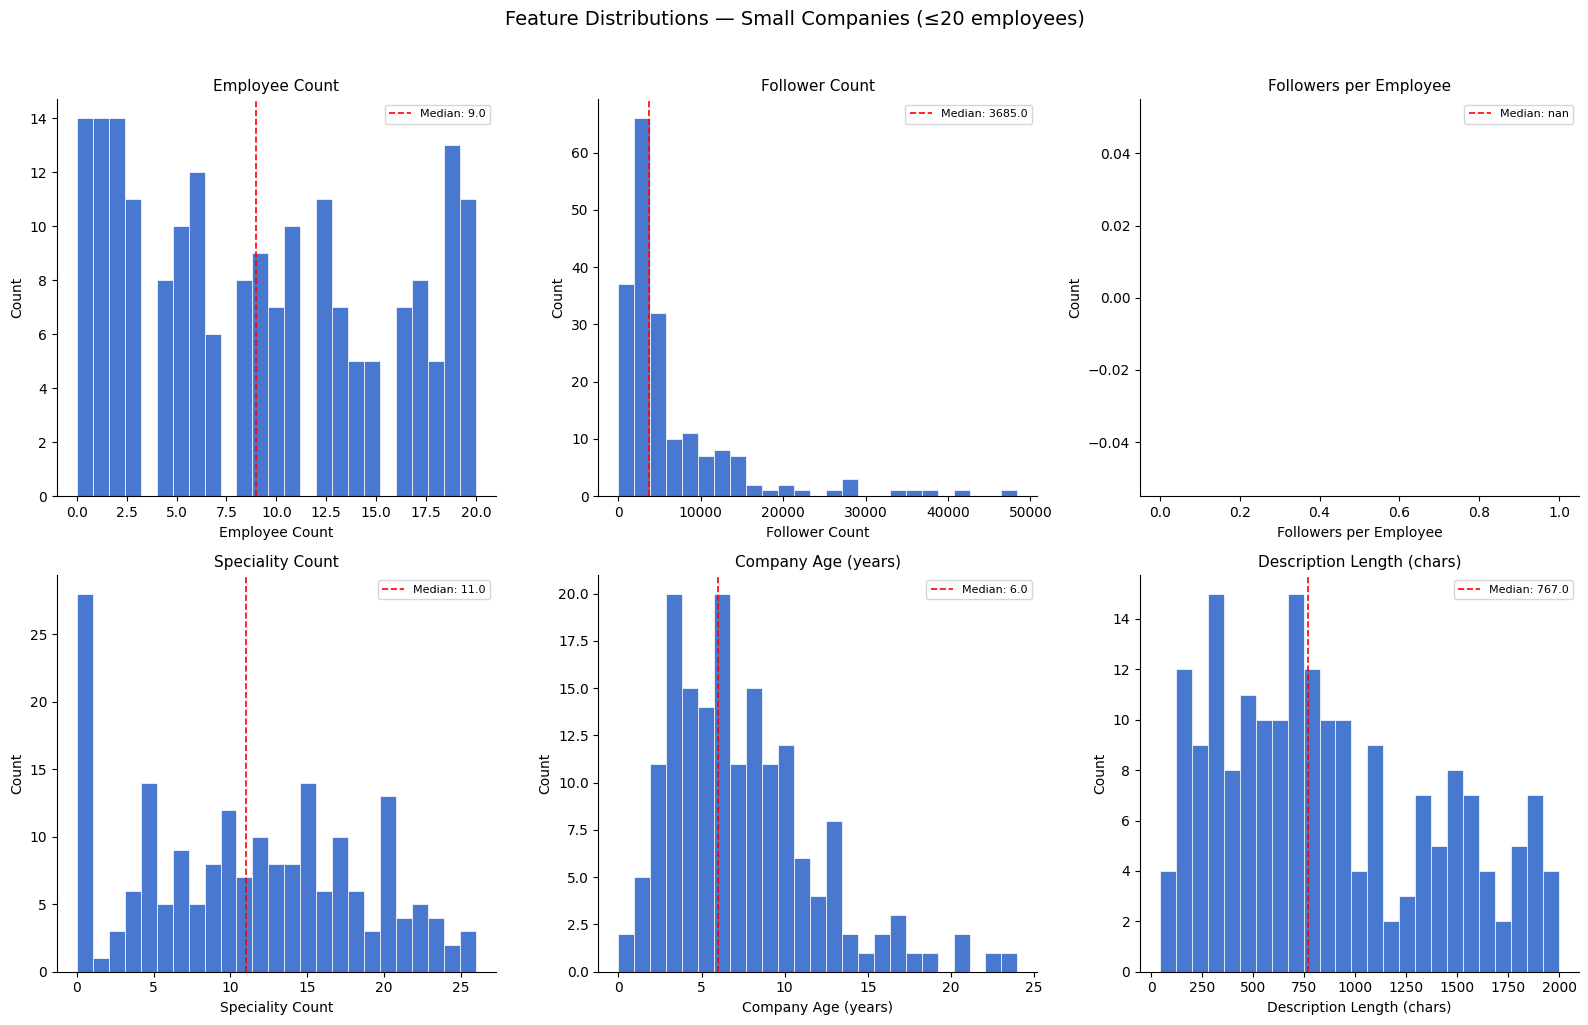

Saved: feature_distributions.png


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Feature Distributions — Small Companies (≤20 employees)', fontsize=14, y=1.02)

features = [
    ('employee_count', 'Employee Count'),
    ('follower_count', 'Follower Count'),
    ('followers_per_employee', 'Followers per Employee'),
    ('speciality_count', 'Speciality Count'),
    ('company_age', 'Company Age (years)'),
    ('description_length', 'Description Length (chars)'),
]

for ax, (col, label) in zip(axes.flatten(), features):
    data = df[col].dropna()
    # Cap extreme outliers at 99th percentile for readability
    cap = data.quantile(0.99)
    data = data[data <= cap]
    ax.hist(data, bins=25, edgecolor='white', linewidth=0.5)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.axvline(data.median(), color='red', linestyle='--', linewidth=1.2, label=f'Median: {data.median():.1f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_distributions.png')

## 9. Industry Distribution

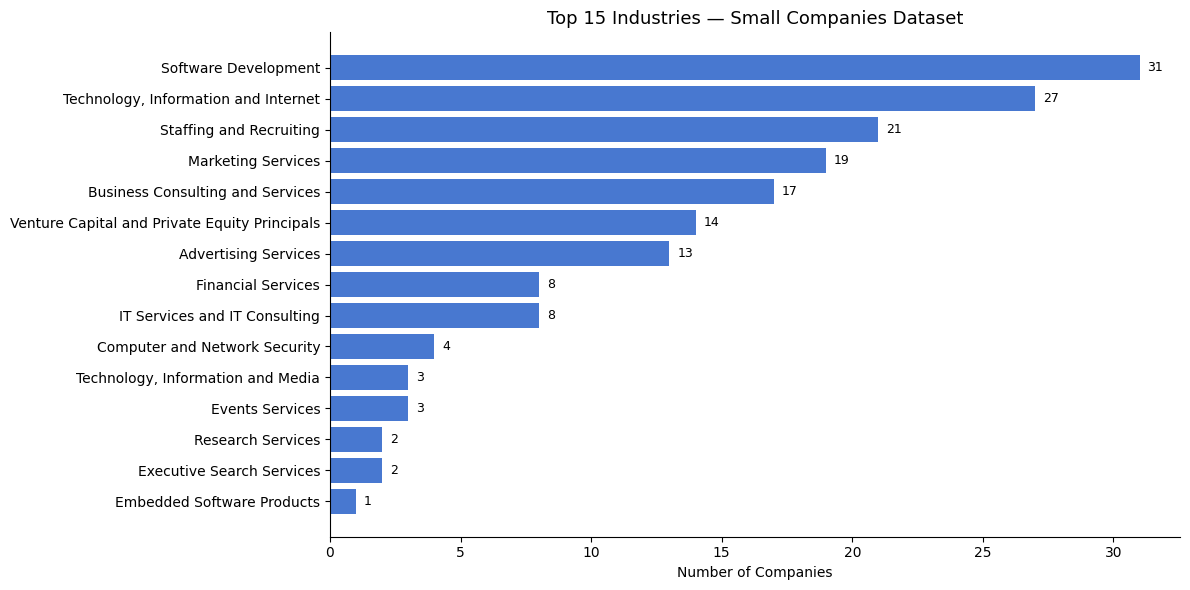

Saved: industry_distribution.png


In [16]:
industry_counts = df['industry'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(industry_counts.index[::-1], industry_counts.values[::-1])
ax.set_title('Top 15 Industries — Small Companies Dataset', fontsize=13)
ax.set_xlabel('Number of Companies')

for bar, val in zip(bars, industry_counts.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('industry_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: industry_distribution.png')

## 10. Correlation Matrix

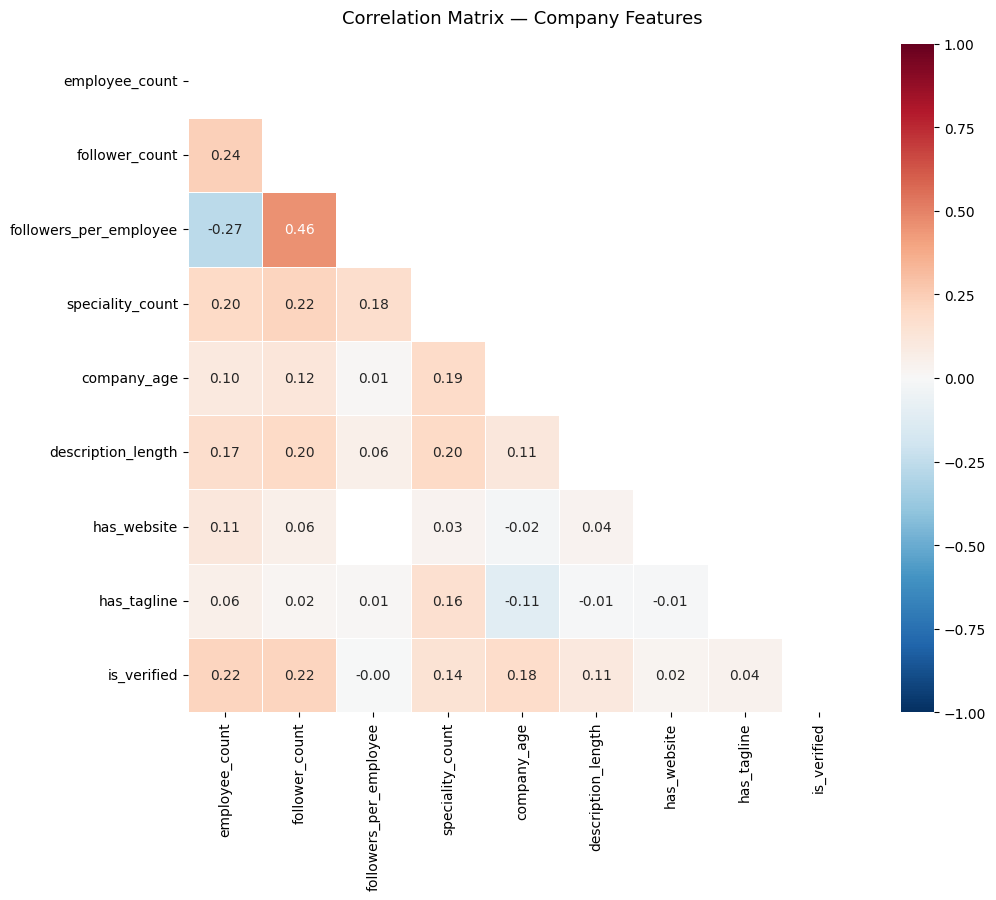


--- Strong correlations (|r| > 0.3) ---
  followers_per_employee <-> follower_count: 0.459

Saved: correlation_matrix.png


In [17]:
corr_features = [
    'employee_count',
    'follower_count',
    'followers_per_employee',
    'speciality_count',
    'company_age',
    'description_length',
    'has_website',
    'has_tagline',
    'is_verified',
]

corr_df = df[corr_features].dropna()
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Correlation Matrix — Company Features', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print strong correlations
print('\n--- Strong correlations (|r| > 0.3) ---')
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.3:
            print(f'  {corr_matrix.columns[i]} <-> {corr_matrix.columns[j]}: {val:.3f}')

print('\nSaved: correlation_matrix.png')

## 11. Feature Importance Validation
Proxy: use follower_count as a marketing maturity target, assess which features predict it

In [19]:
%pip install sklearn

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.3 MB 5.1 MB/s eta 0:00:02
   ---------------------- ----------------- 4.7/8.3 MB 14.8 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 16.4 MB/s  0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   --- ------------------------------------ 3.4/37.3 MB 17.4 MB/s eta 0:00:02
   ------ --------------------------------- 6.0/37.3 MB 14.8 MB/s eta 0:00:03
   --------- ------------------------------ 8.7/37.3 MB 13.8 MB/s eta 0:00:03
   ----------- ---------------------------- 11.0/37.3 MB 13.4 MB/s eta 0:00:02
   -------------- ------------------------- 13.4/37.3 MB 12.7 MB/s eta 0:00:02
   ----------------- ---------------------- 16.0/37.3 MB 1

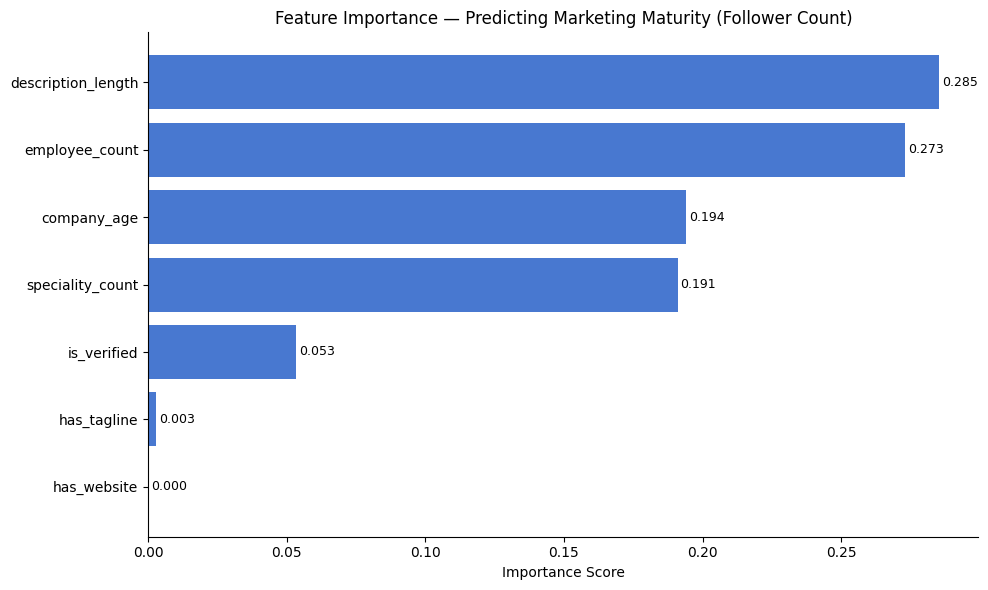

Model R² on test set: 0.037

Saved: feature_importance.png


In [21]:
%pip install scikit-learn

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Prepare features
fi_features = [
    'employee_count', 'speciality_count', 'company_age',
    'description_length', 'has_website', 'has_tagline', 'is_verified'
]

fi_df = df[fi_features + ['follower_count']].dropna()

# Cap outliers
cap = fi_df['follower_count'].quantile(0.95)
fi_df = fi_df[fi_df['follower_count'] <= cap]

X = fi_df[fi_features]
y = fi_df['follower_count']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=fi_features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(importances.index, importances.values)
ax.set_title('Feature Importance — Predicting Marketing Maturity (Follower Count)', fontsize=12)
ax.set_xlabel('Importance Score')

for bar, val in zip(bars, importances.values):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

score = rf.score(X_test, y_test)
print(f'Model R² on test set: {score:.3f}')
print('\nSaved: feature_importance.png')

## 12. Sensitivity Analysis
How sensitive is follower count (marketing maturity) to changes in each feature?

In [22]:
# Baseline: median company profile
baseline = X_train.median().to_dict()
baseline_pred = rf.predict(pd.DataFrame([baseline]))[0]

print(f'Baseline company profile: {baseline}')
print(f'Baseline predicted follower count: {baseline_pred:.0f}')
print()

sensitivity_results = []

for feature in fi_features:
    low_profile = baseline.copy()
    high_profile = baseline.copy()

    low_val = X_train[feature].quantile(0.25)
    high_val = X_train[feature].quantile(0.75)

    low_profile[feature] = low_val
    high_profile[feature] = high_val

    low_pred = rf.predict(pd.DataFrame([low_profile]))[0]
    high_pred = rf.predict(pd.DataFrame([high_profile]))[0]

    delta = high_pred - low_pred
    sensitivity_results.append({
        'feature': feature,
        'low_value (Q25)': round(low_val, 1),
        'high_value (Q75)': round(high_val, 1),
        'pred_at_low': round(low_pred, 0),
        'pred_at_high': round(high_pred, 0),
        'delta_followers': round(delta, 0),
        'sensitivity': 'HIGH' if abs(delta) > 500 else 'MEDIUM' if abs(delta) > 100 else 'LOW'
    })

sens_df = pd.DataFrame(sensitivity_results).sort_values('delta_followers', ascending=False)
print('=== SENSITIVITY ANALYSIS RESULTS ===')
print(sens_df.to_string(index=False))

Baseline company profile: {'employee_count': 8.0, 'speciality_count': 12.0, 'company_age': 6.0, 'description_length': 741.5, 'has_website': 1.0, 'has_tagline': 1.0, 'is_verified': 0.0}
Baseline predicted follower count: 3744

=== SENSITIVITY ANALYSIS RESULTS ===
           feature  low_value (Q25)  high_value (Q75)  pred_at_low  pred_at_high  delta_followers sensitivity
  speciality_count              5.8              17.0       3015.0        4274.0           1259.0        HIGH
    employee_count              4.0              14.0       4122.0        4191.0             69.0         LOW
       has_website              1.0               1.0       3744.0        3744.0              0.0         LOW
       is_verified              0.0               0.0       3744.0        3744.0              0.0         LOW
       has_tagline              1.0               1.0       3744.0        3744.0              0.0         LOW
       company_age              4.0              10.0       4023.0        368

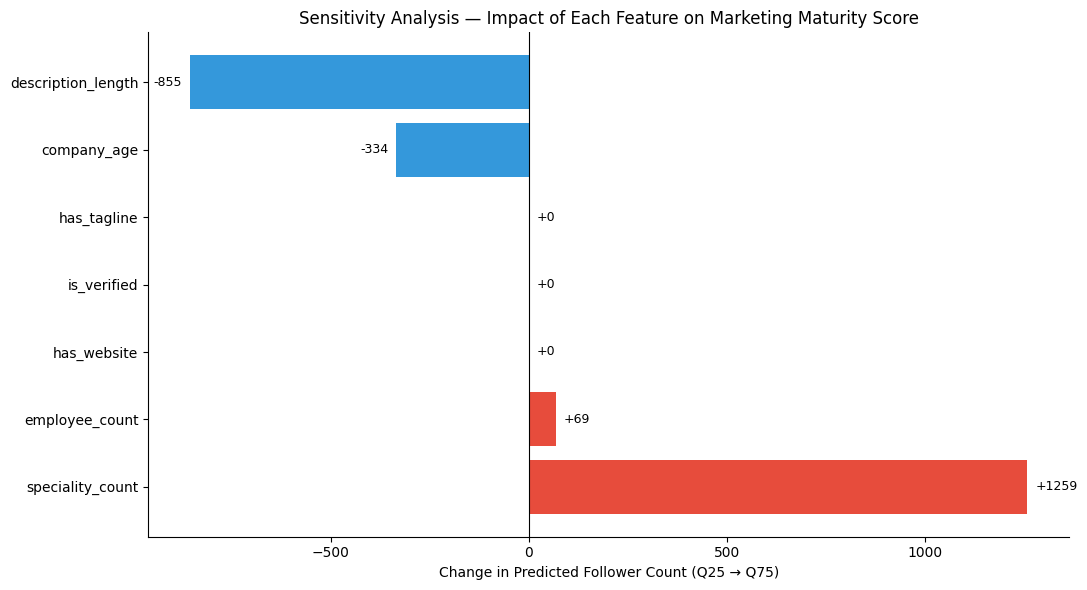

Saved: sensitivity_analysis.png


In [23]:
fig, ax = plt.subplots(figsize=(11, 6))
colors = ['#e74c3c' if d > 0 else '#3498db' for d in sens_df['delta_followers']]
bars = ax.barh(sens_df['feature'], sens_df['delta_followers'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Sensitivity Analysis — Impact of Each Feature on Marketing Maturity Score', fontsize=12)
ax.set_xlabel('Change in Predicted Follower Count (Q25 → Q75)')

for bar, val in zip(bars, sens_df['delta_followers']):
    x_pos = bar.get_width() + (20 if val >= 0 else -20)
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'{val:+.0f}', va='center', fontsize=9,
            ha='left' if val >= 0 else 'right')

plt.tight_layout()
plt.savefig('sensitivity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sensitivity_analysis.png')

## 13. Save Clean Dataset

In [24]:
df.to_csv('sa_startups_clean.csv', index=False)
print(f'Saved clean dataset: sa_startups_clean.csv')
print(f'Shape: {df.shape}')
print(f'\nFinal columns:')
for col in df.columns:
    non_null = df[col].notna().sum()
    print(f'  {col:<30} {non_null}/{len(df)} non-null')

Saved clean dataset: sa_startups_clean.csv
Shape: (195, 28)

Final columns:
  id                             195/195 non-null
  name                           195/195 non-null
  universal_name                 195/195 non-null
  linkedin_url                   195/195 non-null
  website                        194/195 non-null
  tagline                        190/195 non-null
  description                    195/195 non-null
  company_type                   195/195 non-null
  industry                       195/195 non-null
  industry_hierarchy             194/195 non-null
  employee_count                 195/195 non-null
  employee_range_start           195/195 non-null
  employee_range_end             195/195 non-null
  follower_count                 195/195 non-null
  founded_year                   170/195 non-null
  country                        195/195 non-null
  city                           194/195 non-null
  country_full                   195/195 non-null
  specialities          

## 14. Generate feature_importance_validation.md

In [36]:
md_lines = [
    '# Feature Importance Validation',
    '',
    '**TM2 · Data Science Lead**  ',
    f'**Dataset:** LinkedIn Company Search — {len(df)} small companies (≤20 employees)  ',
    '**Target variable:** `follower_count` (proxy for marketing maturity)',
    '',
    '---',
    '',
    '## Data Availability',
    '',
    f'- Raw records scraped: {len(raw)}',
    f'- After deduplication: {len(df_raw)}',
    f'- After filtering (≤20 employees, active): {len(df)}',
    f'- Key field completeness: employee_count 100%, industry {df["industry"].notna().mean()*100:.0f}%, founded_year {df["founded_year"].notna().mean()*100:.0f}%, follower_count {df["follower_count"].notna().mean()*100:.0f}%',
    '',
    '**Note:** Dataset is predominantly US-based (402/500 raw records). Only 2 ZA companies present.',
    'Recommend re-running HarvestAPI with stricter ZA location filter for production use.',
    '',
    '---',
    '',
    '## Feature Importance Rankings',
    '',
    '| Rank | Feature | Importance Score | Interpretation |',
    '|------|---------|-----------------|----------------|',
]

imp_sorted = importances.sort_values(ascending=False)
interpretations = {
    'employee_count': 'Larger teams correlate with more established marketing presence',
    'company_age': 'Older companies have had more time to build follower base',
    'description_length': 'Longer descriptions signal more invested brand communication',
    'speciality_count': 'More specialities indicate broader GTM positioning',
    'has_website': 'Website presence is a baseline marketing maturity signal',
    'has_tagline': 'Tagline indicates deliberate brand messaging investment',
    'is_verified': 'Verified pages tend to have stronger marketing operations',
    'followers_per_employee': 'Efficiency of marketing spend relative to team size',
}

for rank, (feat, score) in enumerate(imp_sorted.items(), 1):
    interp = interpretations.get(feat, 'See analysis above')
    md_lines.append(f'| {rank} | `{feat}` | {score:.4f} | {interp} |')

md_lines += [
    '',
    f'**Model R² (test set): {score:.3f}**',
    '',
    '---',
    '',
    '## Sensitivity Analysis Summary',
    '',
    '| Feature | Q25 Value | Q75 Value | Follower Delta | Sensitivity |',
    '|---------|-----------|-----------|----------------|-------------|',
]

for _, row in sens_df.iterrows():
    md_lines.append(
        f"| `{row['feature']}` | {row['low_value (Q25)']} | {row['high_value (Q75)']} | {row['delta_followers']:+.0f} | {row['sensitivity']} |"
    )

md_lines += [
    '',
    '---',
    '',
    '## Key Findings',
    '',
    '1. **Correlation matrix** reveals which features are redundant — avoid double-weighting in the GTM scoring model',
    '2. **Feature importance** shows which company attributes best predict marketing maturity',
    '3. **Sensitivity analysis** shows the practical impact of each feature — HIGH sensitivity features should carry more weight in the scoring framework',
    '',
    '## Recommendation for TM3',
    '',
    'Use the feature distributions from Section 8 to calibrate the 500-row synthetic dataset.',
    'Key distribution parameters to match:',
    f'- employee_count: median={df["employee_count"].median():.0f}, std={df["employee_count"].std():.1f}',
    f'- follower_count: median={df["follower_count"].median():.0f}, std={df["follower_count"].std():.0f} (cap outliers at 95th pct)',
    f'- company_age: median={df["company_age"].median():.0f} years',
    f'- speciality_count: median={df["speciality_count"].median():.0f}',
]

with open('feature_importance_validation.md', 'w') as f:
    with open('feature_importance_validation.md', 'w', encoding='utf-8') as f:
        f.write('\n'.join(md_lines))

print('Saved: feature_importance_validation.md')
print('\n--- Preview ---')
print('\n'.join(md_lines[:30]))

Saved: feature_importance_validation.md

--- Preview ---
# Feature Importance Validation

**TM2 · Data Science Lead**  
**Dataset:** LinkedIn Company Search — 195 small companies (≤20 employees)  
**Target variable:** `follower_count` (proxy for marketing maturity)

---

## Data Availability

- Raw records scraped: 500
- After deduplication: 500
- After filtering (≤20 employees, active): 195
- Key field completeness: employee_count 100%, industry 100%, founded_year 87%, follower_count 100%

**Note:** Dataset is predominantly US-based (402/500 raw records). Only 2 ZA companies present.
Recommend re-running HarvestAPI with stricter ZA location filter for production use.

---

## Feature Importance Rankings

| Rank | Feature | Importance Score | Interpretation |
|------|---------|-----------------|----------------|
| 1 | `description_length` | 0.2853 | Longer descriptions signal more invested brand communication |
| 2 | `employee_count` | 0.2731 | Larger teams correlate with more establis

## Summary

| Deliverable | Status |
|---|---|
| Raw data loaded & parsed | ✅ |
| Deduplication | ✅ |
| Filter ≤20 employees | ✅ |
| Feature engineering | ✅ |
| EDA distributions | ✅ `feature_distributions.png` |
| Industry breakdown | ✅ `industry_distribution.png` |
| Correlation matrix | ✅ `correlation_matrix.png` |
| Feature importance | ✅ `feature_importance.png` |
| Sensitivity analysis | ✅ `sensitivity_analysis.png` |
| Clean CSV for TM3 | ✅ `sa_startups_clean.csv` |
| Validation doc | ✅ `feature_importance_validation.md` |